# 多頻道 Shorts 分析模板（template_multi）

適用情境：類別有 3+ 個頻道（如運動、時事、介紹食物、餐廳推廣）。
核心檢定：ANOVA（F_oneway）；OLS 含 C(channel_title) dummy。
title_length 切點改用 qcut 三分位數（避免某類別全部都 <15 字導致空組）。

## 0. 參數

In [1]:
# === 參數區 ===========================================================
# 改類別只要改這三行；下方所有 cell 都引用這些變數
CSV_TIMESTAMP = "20260527-065044"      # 改這裡切換不同類別的資料
TARGET_CHANNELS = None                  # None = 全部；或填 list 過濾特定頻道
CATEGORY_NAME = "時事"               # 用於圖表標題、檔名
# ====================================================================

## 1. 匯入函式庫

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 中文字體（macOS 預設沒有 Microsoft 系列，使用 sans-serif 後備）
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang TC', 'Microsoft JhengHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")

# 將 _templates/ 加入 sys.path 以便 import content_labeling
TPL_DIR = Path('../../analysis/_templates').resolve()
if str(TPL_DIR) not in sys.path:
    sys.path.insert(0, str(TPL_DIR))

print("✓ 函式庫載入完成")


✓ 函式庫載入完成


## 2. 載入 CSV

In [3]:
# 載入資料（路徑從 analysis/<cat>/ 回退兩層到 final project/）
df = pd.read_csv(f'../../data/processed/channel_videos_{CSV_TIMESTAMP}.csv', encoding='utf-8')
df_channels = pd.read_csv(f'../../data/processed/channels_{CSV_TIMESTAMP}.csv', encoding='utf-8')

if TARGET_CHANNELS is not None:
    df = df[df['channel_title'].isin(TARGET_CHANNELS)].copy()

print(f"✓ 資料載入：{len(df)} 列影片 / {len(df_channels)} 列頻道")
print(f"頻道：{df['channel_title'].unique().tolist()}")


✓ 資料載入：1214 列影片 / 5 列頻道
頻道：['Johnny Harris', '志祺七七', 'Vox', 'Real Fake', '喵耳電波']


## 3. 檢視資料結構

In [4]:
print(df.dtypes)
print()
print('頻道列表：', df['channel_title'].unique())
print()
print(df.head())


video_id                str
title                   str
description             str
channel_id              str
channel_title           str
published_at            str
category_id           int64
tags                    str
default_language        str
duration_iso            str
duration_sec          int64
definition              str
caption                bool
view_count            int64
like_count          float64
comment_count         int64
favorite_count        int64
topic_categories        str
fetched_at              str
dtype: object

頻道列表： <StringArray>
['Johnny Harris', '志祺七七', 'Vox', 'Real Fake', '喵耳電波']
Length: 5, dtype: str

      video_id                                              title  \
0  Pc6sCGS6Jfc  Inside the $200 Billion Mormon Empire. (full d...   
1  zOp6FCBn8ZA                            Why we need more silver   
2  nAFw5i39m9I             China’s Dirty Money Problem, Explained   
3  2PnTzFq_O4o                     Why We Still Have 12,000 Nukes   
4  vWg2bI2P

## 4. 資料清理與前處理

In [5]:
# 資料清理 + 派生欄位
df_clean = df.copy()
df_clean['published_at'] = pd.to_datetime(df_clean['published_at'])
df_clean['fetched_at'] = pd.to_datetime(df_clean['fetched_at'])

# 標題長度（混合 CJK + 英文之視覺字符數）
df_clean['title_length'] = df_clean['title'].fillna('').apply(len)

# CJK / EN 分開計，跨類別比較時較公平
def count_cjk(s):
    return sum(1 for c in str(s) if '一' <= c <= '鿿')

def count_en_words(s):
    import re
    return len(re.findall(r'[A-Za-z]+', str(s)))

df_clean['title_length_cjk'] = df_clean['title'].fillna('').apply(count_cjk)
df_clean['title_length_en'] = df_clean['title'].fillna('').apply(count_en_words)

# tag_count: 用 flatten_video 的 '|' 串接，注意 NaN
df_clean['tag_count'] = df_clean['tags'].fillna('').apply(lambda s: 0 if not s else len(s.split('|')))

# Shorts 判定（沿用 Reg/02、Reg/03 的 180 秒閾值）
df_shorts = df_clean[df_clean['duration_sec'] <= 180].copy()

print(f"原始：{len(df_clean)}  Shorts (≤180s)：{len(df_shorts)}")
print(f"  每頻道 Shorts 篇數：")
print(df_shorts['channel_title'].value_counts())


原始：1214  Shorts (≤180s)：964
  每頻道 Shorts 篇數：
channel_title
喵耳電波             286
志祺七七             247
Johnny Harris    212
Vox              211
Real Fake          8
Name: count, dtype: int64


## 4.5 內容貼標（Layer 1-3）

In [6]:
# === §4.5 內容貼標（Layer 1-3） ============================
# 此 cell 由 content_labeling.py 注入
import content_labeling as cl

df_with_topics, topic_counts = cl.explode_topic_categories(df_shorts)
df_lab = cl.apply_keyword_labels(df_with_topics, text_cols=("title", "tags"))
buckets = cl.load_keyword_dict()
label_cols = [f"has_{b}" for b in buckets]

print("Layer 1 — topic 全體計數 (Top 15)：")
print(topic_counts.head(15))
print()

topic_dist = cl.topic_distribution_by_channel(df_with_topics)
print("Layer 1 — 頻道 × topic 比例：")
print(topic_dist)
print()

print("Layer 2 — 規則式關鍵字命中率（按頻道）：")
print(df_lab.groupby('channel_title')[label_cols].mean().round(3))
print()

try:
    tfidf = cl.tfidf_top_keywords_by_channel(df_lab, n=15)
    print("Layer 3 — TF-IDF Top 15 keywords / channel：")
    for ch, kws in tfidf.items():
        print(f"\n{ch}:")
        for kw, sc in kws:
            print(f"  {kw:20s}  {sc:.4f}")
except RuntimeError as e:
    print(f"Layer 3 跳過：{e}")


Building prefix dict from the default dictionary ...


Loading model from cache /var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/jieba.cache


Layer 1 — topic 全體計數 (Top 15)：
Entertainment              376
Society                    284
Politics                   183
Lifestyle_(sociology)      115
Health                      83
Video_game_culture          67
Knowledge                   37
Military                    34
Film                        18
Fashion                     16
Pet                         16
Humour                      11
Role-playing_video_game     10
Action_game                 10
Food                         8
dtype: int64

Layer 1 — 頻道 × topic 比例：
               Knowledge  Politics  Lifestyle_(sociology)       Pet   Tourism  \
Johnny Harris   0.150943  0.372642               0.061321  0.004717  0.009434   
Real Fake       0.000000  0.000000               0.000000  0.000000  0.000000   
Vox             0.023697  0.483412               0.170616  0.028436  0.004739   
喵耳電波            0.000000  0.006993               0.076923  0.003497  0.000000   
志祺七七            0.000000  0.000000               0.178138  0

Loading model cost 0.224 seconds.


Prefix dict has been built successfully.


Layer 3 — TF-IDF Top 15 keywords / channel：

Johnny Harris:
  the                   0.4903
  why                   0.4289
  is                    0.4046
  how                   0.2266
  are                   0.2104
  to                    0.1780
  in                    0.1612
  us                    0.1295
  this                  0.1133
  israel                0.1103
  of                    0.1075
  russia                0.1003
  china                 0.0971
  war                   0.0890
  on                    0.0809

Real Fake:
  tedua                 0.5605
  per                   0.5605
  intro                 0.5605
  izi                   0.1868
  charles               0.1507

Vox:
  the                   0.5575
  is                    0.2847
  to                    0.2701
  why                   0.2555
  how                   0.2044
  in                    0.1939
  are                   0.1606
  trump                 0.1460
  of                    0.1394
  for                  

## 5. 描述性統計

In [7]:
# 描述性統計
metrics = ['view_count', 'like_count', 'comment_count', 'duration_sec',
           'title_length', 'tag_count']
print("Shorts 主要指標統計：")
for m in metrics:
    if m in df_shorts.columns:
        d = df_shorts[m].dropna()
        if len(d) == 0:
            continue
        print(f"  {m:15s} mean={d.mean():>12,.1f}  median={d.median():>10,.1f}  std={d.std():>12,.1f}")

# 頻道級摘要
print("\n每頻道摘要：")
agg = df_shorts.groupby('channel_title').agg(
    n_shorts=('video_id', 'count'),
    mean_view=('view_count', 'mean'),
    median_view=('view_count', 'median'),
    mean_like=('like_count', 'mean'),
    mean_comment=('comment_count', 'mean'),
)
print(agg)


Shorts 主要指標統計：
  view_count      mean=   533,435.6  median= 149,132.0  std= 1,216,268.8
  like_count      mean=    21,561.0  median=   3,360.0  std=    59,320.7
  comment_count   mean=       685.4  median=     153.0  std=     2,144.0
  duration_sec    mean=        54.4  median=      48.0  std=        27.8
  title_length    mean=        35.1  median=      35.0  std=        17.5
  tag_count       mean=        18.7  median=       3.0  std=        25.6

每頻道摘要：
               n_shorts     mean_view  median_view     mean_like  mean_comment
channel_title                                                                 
Johnny Harris       212  1.730981e+06     920257.5  83528.824645   2431.778302
Real Fake             8  9.611250e+02        211.0     17.250000      5.250000
Vox                 211  4.172553e+04      29698.0    885.180095     49.526066
喵耳電波                286  2.919258e+05     186478.0   5884.520979    299.356643
志祺七七                247  2.225154e+05     156419.0   5136.688259 

## 6. 發佈時間趨勢

In [8]:
# 發佈時間特徵
df_shorts['pub_date'] = df_shorts['published_at'].dt.date
df_shorts['pub_hour'] = df_shorts['published_at'].dt.hour
df_shorts['pub_day_of_week'] = df_shorts['published_at'].dt.day_name()
df_shorts['pub_hour_band'] = pd.cut(df_shorts['pub_hour'], bins=[-1,5,11,17,21,24],
                                     labels=['深夜','早','中','下','晚'])

# 按小時
print("按發佈時段平均觀看數：")
print(df_shorts.groupby('pub_hour_band', observed=False)['view_count'].mean().round(0))


按發佈時段平均觀看數：
pub_hour_band
深夜    310437.0
早     237592.0
中     624281.0
下     964093.0
晚     560413.0
Name: view_count, dtype: float64


## 7. 相關性分析

In [9]:
# 相關性分析
analysis_cols = ['view_count', 'like_count', 'comment_count', 'duration_sec',
                 'title_length', 'tag_count']
corr = df_shorts[analysis_cols].corr()
print("相關係數矩陣：")
print(corr.round(3))

print("\n與 view_count 的相關性顯著性檢定（Pearson）：")
for col in ['like_count', 'comment_count', 'duration_sec', 'title_length', 'tag_count']:
    d = df_shorts[[col, 'view_count']].dropna()
    if len(d) > 2:
        r, p = stats.pearsonr(d[col], d['view_count'])
        sig = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"
        print(f"  {col:15s} r={r:+.4f}  p={p:.4e} {sig}")


相關係數矩陣：
               view_count  like_count  comment_count  duration_sec  \
view_count          1.000       0.956          0.751        -0.017   
like_count          0.956       1.000          0.697        -0.001   
comment_count       0.751       0.697          1.000         0.010   
duration_sec       -0.017      -0.001          0.010         1.000   
title_length       -0.051      -0.009         -0.036         0.363   
tag_count          -0.127      -0.171         -0.107        -0.254   

               title_length  tag_count  
view_count           -0.051     -0.127  
like_count           -0.009     -0.171  
comment_count        -0.036     -0.107  
duration_sec          0.363     -0.254  
title_length          1.000     -0.693  
tag_count            -0.693      1.000  

與 view_count 的相關性顯著性檢定（Pearson）：
  like_count      r=+0.9561  p=0.0000e+00 ***
  comment_count   r=+0.7513  p=8.0894e-176 ***
  duration_sec    r=-0.0174  p=5.9039e-01 ns
  title_length    r=-0.0506  p=1.1676e-01 

## 7.5 內容標籤與觀看數的關係

In [10]:
# === §7.5 內容標籤與觀看數的關係 ==========================
# 此 cell 由 content_labeling.py 注入：卡方 + logistic
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf

# 高觀看 = top quartile（每頻道內或整體）
view_q3 = df_lab['view_count'].quantile(0.75)
df_lab['top_quartile'] = (df_lab['view_count'] >= view_q3).astype(int)

print(f"top_quartile 門檻：view_count >= {view_q3:,.0f}")
print()

print("每個 label vs 高觀看 卡方檢定：")
for col in label_cols:
    if df_lab[col].sum() < 5 or df_lab[col].sum() > len(df_lab) - 5:
        print(f"  {col:25s} (樣本太集中, 跳過)")
        continue
    tab = pd.crosstab(df_lab[col], df_lab['top_quartile'])
    chi2, p, _, _ = chi2_contingency(tab)
    sig = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"
    print(f"  {col:25s} chi2={chi2:6.2f}  p={p:.4e} {sig}")

# Logistic：P(top_quartile) ~ has_*
formula = "top_quartile ~ " + " + ".join(label_cols)
try:
    model = smf.logit(formula=formula, data=df_lab).fit(disp=False)
    print("\nLogistic 迴歸：")
    print(model.summary())
except Exception as e:
    print(f"\nLogistic 跳過：{e}")


top_quartile 門檻：view_count >= 451,397

每個 label vs 高觀看 卡方檢定：
  has_教學教育                  chi2=  1.96  p=1.6115e-01 ns
  has_挑戰對決                  chi2=  0.01  p=9.0302e-01 ns
  has_搞笑迷因                  chi2=  3.21  p=7.3269e-02 ns
  has_開箱評測                  (樣本太集中, 跳過)
  has_互動誘導                  (樣本太集中, 跳過)
  has_情緒詞                   chi2=  0.03  p=8.6102e-01 ns
  has_品牌推廣                  (樣本太集中, 跳過)
  has_食物                    chi2=  0.98  p=3.2269e-01 ns
  has_運動                    (樣本太集中, 跳過)
  has_問句                    chi2= 17.52  p=2.8432e-05 ***

Logistic 迴歸：
                           Logit Regression Results                           
Dep. Variable:           top_quartile   No. Observations:                  964
Model:                          Logit   Df Residuals:                      953
Method:                           MLE   Df Model:                           10
Date:                Wed, 27 May 2026   Pseudo R-squ.:                 0.02979
Time:                      

/Users/waynliu/Documents/NTU/台大/大二下/統計一下/final project/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 8. Top 10 視覺化

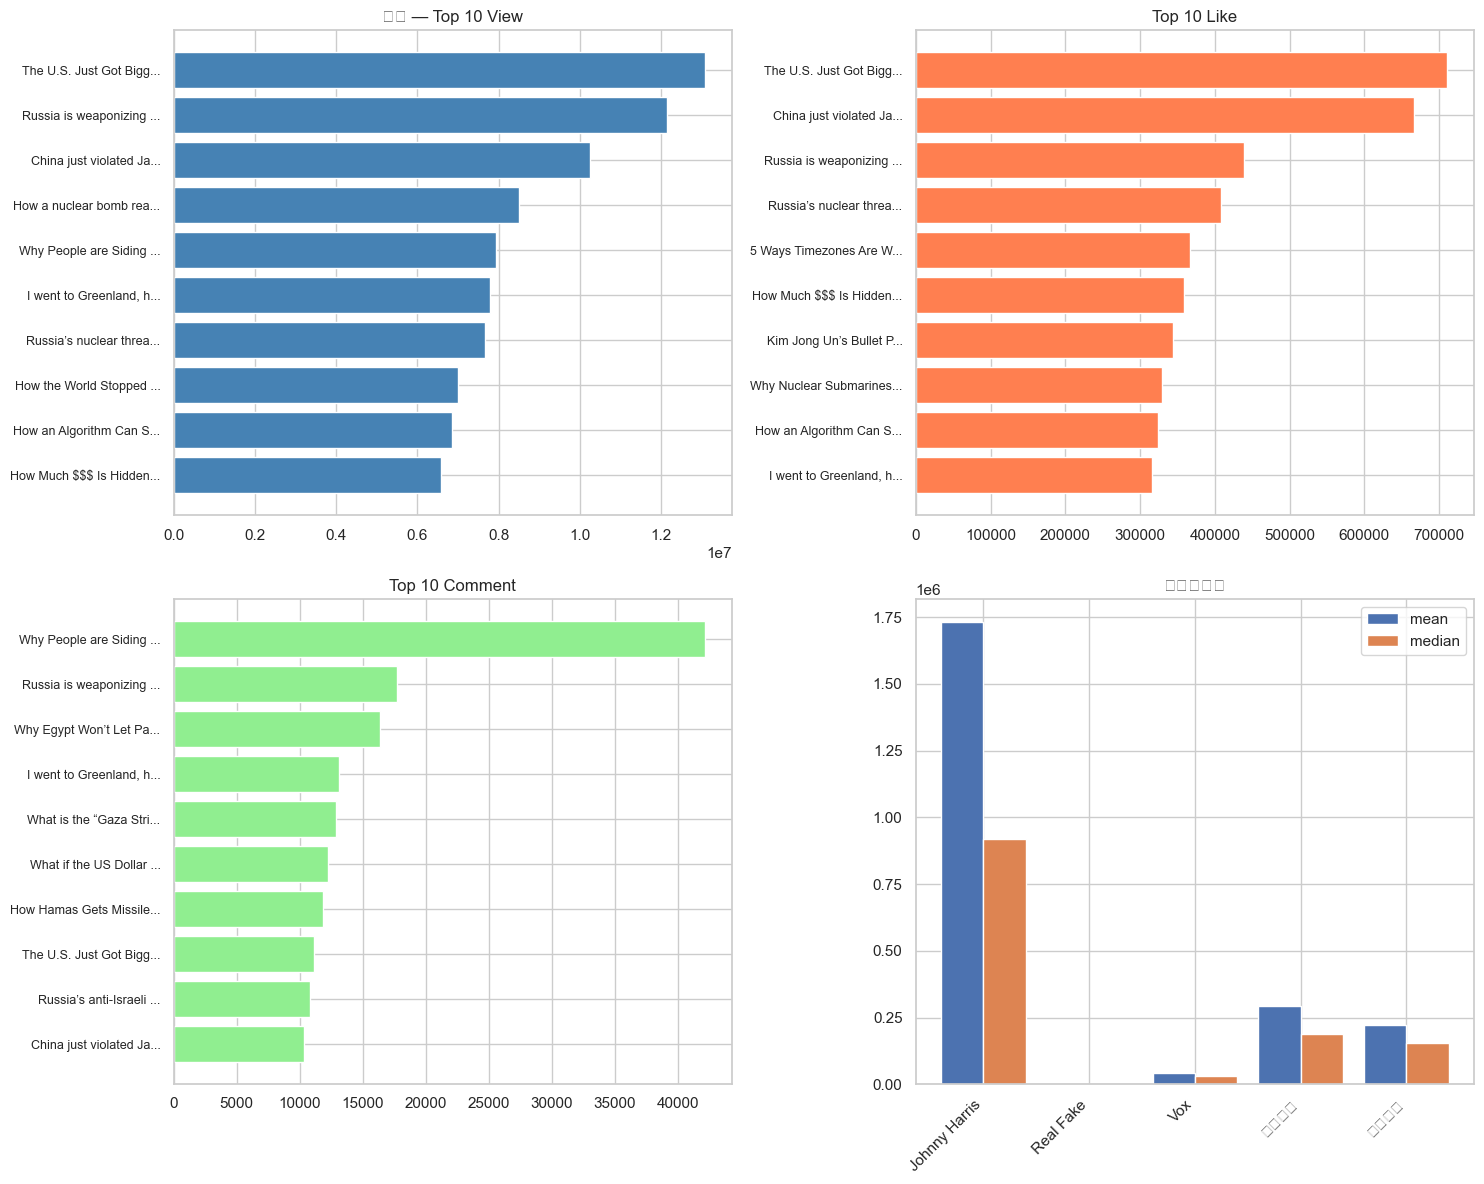

In [11]:
# Top 10 視覺化
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

t10v = df_shorts.nlargest(10, 'view_count')
axes[0,0].barh(range(len(t10v)), t10v['view_count'].values, color='steelblue')
axes[0,0].set_yticks(range(len(t10v)))
axes[0,0].set_yticklabels([f"{t[:22]}..." if len(str(t))>22 else str(t) for t in t10v['title']], fontsize=9)
axes[0,0].set_title(f'{CATEGORY_NAME} — Top 10 View'); axes[0,0].invert_yaxis()

t10l = df_shorts.nlargest(10, 'like_count')
axes[0,1].barh(range(len(t10l)), t10l['like_count'].values, color='coral')
axes[0,1].set_yticks(range(len(t10l)))
axes[0,1].set_yticklabels([f"{t[:22]}..." if len(str(t))>22 else str(t) for t in t10l['title']], fontsize=9)
axes[0,1].set_title('Top 10 Like'); axes[0,1].invert_yaxis()

t10c = df_shorts.nlargest(10, 'comment_count')
axes[1,0].barh(range(len(t10c)), t10c['comment_count'].values, color='lightgreen')
axes[1,0].set_yticks(range(len(t10c)))
axes[1,0].set_yticklabels([f"{t[:22]}..." if len(str(t))>22 else str(t) for t in t10c['title']], fontsize=9)
axes[1,0].set_title('Top 10 Comment'); axes[1,0].invert_yaxis()

ch_summary = df_shorts.groupby('channel_title')['view_count'].agg(['mean','median']).reset_index()
x = range(len(ch_summary))
axes[1,1].bar([i-0.2 for i in x], ch_summary['mean'], 0.4, label='mean')
axes[1,1].bar([i+0.2 for i in x], ch_summary['median'], 0.4, label='median')
axes[1,1].set_xticks(list(x))
axes[1,1].set_xticklabels(ch_summary['channel_title'], rotation=45, ha='right')
axes[1,1].set_title('頻道觀看數'); axes[1,1].legend()

plt.tight_layout(); plt.show()


## 9. ANOVA（多因子）

In [12]:
from scipy.stats import f_oneway

# title_length 用 qcut 三等分位數（動態），避免空組
df_shorts['title_length_group'] = pd.qcut(df_shorts['title_length'], q=3,
                                           labels=['短','中','長'], duplicates='drop')

# tag_count: 0 / 1-3 / 4+
df_shorts['tag_count_group'] = pd.cut(df_shorts['tag_count'], bins=[-1,0,3,1000],
                                      labels=['無標籤','1-3','4+'])

print("=" * 70)
print("【RQ1】標題長度 vs 觀看數")
for name, g in df_shorts.groupby('title_length_group', observed=False):
    v = g['view_count'].dropna()
    if len(v): print(f"  {name}: n={len(v)}  mean={v.mean():>12,.0f}  median={v.median():>10,.0f}")
grps = [g['view_count'].dropna().values for _, g in df_shorts.groupby('title_length_group', observed=False) if len(g)>0]
if len(grps) >= 2:
    f, p = f_oneway(*grps)
    print(f"ANOVA F={f:.4f}  p={p:.4e}")

print("\n" + "=" * 70)
print("【RQ3】標籤數量 vs 觀看數")
for name, g in df_shorts.groupby('tag_count_group', observed=False):
    v = g['view_count'].dropna()
    if len(v): print(f"  {name}: n={len(v)}  mean={v.mean():>12,.0f}  median={v.median():>10,.0f}")
grps = [g['view_count'].dropna().values for _, g in df_shorts.groupby('tag_count_group', observed=False) if len(g)>0]
if len(grps) >= 2:
    f, p = f_oneway(*grps)
    print(f"ANOVA F={f:.4f}  p={p:.4e}")

print("\n" + "=" * 70)
print("【控制】頻道 vs 觀看數")
for ch, g in df_shorts.groupby('channel_title'):
    v = g['view_count'].dropna()
    print(f"  {ch}: n={len(v)}  mean={v.mean():>12,.0f}")
grps = [g['view_count'].dropna().values for _, g in df_shorts.groupby('channel_title') if len(g)>0]
if len(grps) >= 2:
    f, p = f_oneway(*grps)
    print(f"ANOVA F={f:.4f}  p={p:.4e}")


【RQ1】標題長度 vs 觀看數
  短: n=325  mean=     489,807  median=   215,502
  中: n=324  mean=     716,823  median=   224,520
  長: n=315  mean=     389,822  median=    50,952


ANOVA F=6.1531  p=2.2116e-03

【RQ3】標籤數量 vs 觀看數
  無標籤: n=119  mean=   1,708,987  median= 1,061,409
  1-3: n=457  mean=     139,430  median=    56,035
  4+: n=388  mean=     636,966  median=   240,160
ANOVA F=97.1331  p=3.8007e-39

【控制】頻道 vs 觀看數
  Johnny Harris: n=212  mean=   1,730,981
  Real Fake: n=8  mean=         961
  Vox: n=211  mean=      41,726
  喵耳電波: n=286  mean=     291,926
  志祺七七: n=247  mean=     222,515
ANOVA F=92.9100  p=8.4153e-67


## 10. 迴歸（多模型）

In [13]:
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_reg = df_shorts[['view_count','duration_sec','title_length','tag_count','channel_title']].dropna()
print(f"迴歸樣本數：{len(df_reg)}")

if len(df_reg) >= 10:
    scaler = StandardScaler()
    feats = ['duration_sec','title_length','tag_count']
    dfs = df_reg.copy()
    dfs[feats] = scaler.fit_transform(df_reg[feats])

    m1 = smf.ols('view_count ~ duration_sec + title_length + tag_count', data=dfs).fit()
    m2 = smf.ols('view_count ~ duration_sec + title_length + tag_count + C(channel_title)', data=dfs).fit()
    print("Model 1：")
    print(m1.summary())
    print("\nModel 2（含 channel dummy）：")
    print(m2.summary())
    print(f"\nM1 R²={m1.rsquared:.4f}  Adj R²={m1.rsquared_adj:.4f}")
    print(f"M2 R²={m2.rsquared:.4f}  Adj R²={m2.rsquared_adj:.4f}")

    X = m1.model.exog
    names = m1.model.exog_names
    vif = pd.DataFrame({"Variable": names[1:],
                        "VIF": [variance_inflation_factor(X, i) for i in range(1, X.shape[1])]})
    print("\nVIF：")
    print(vif.to_string(index=False))
else:
    print("樣本太少，跳過迴歸")


迴歸樣本數：964
Model 1：
                            OLS Regression Results                            
Dep. Variable:             view_count   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     17.98
Date:                Wed, 27 May 2026   Prob (F-statistic):           2.34e-11
Time:                        14:56:18   Log-Likelihood:                -14848.
No. Observations:                 964   AIC:                         2.970e+04
Df Residuals:                     960   BIC:                         2.972e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     5.334e+05   3.8

## 11. ANOVA 視覺化

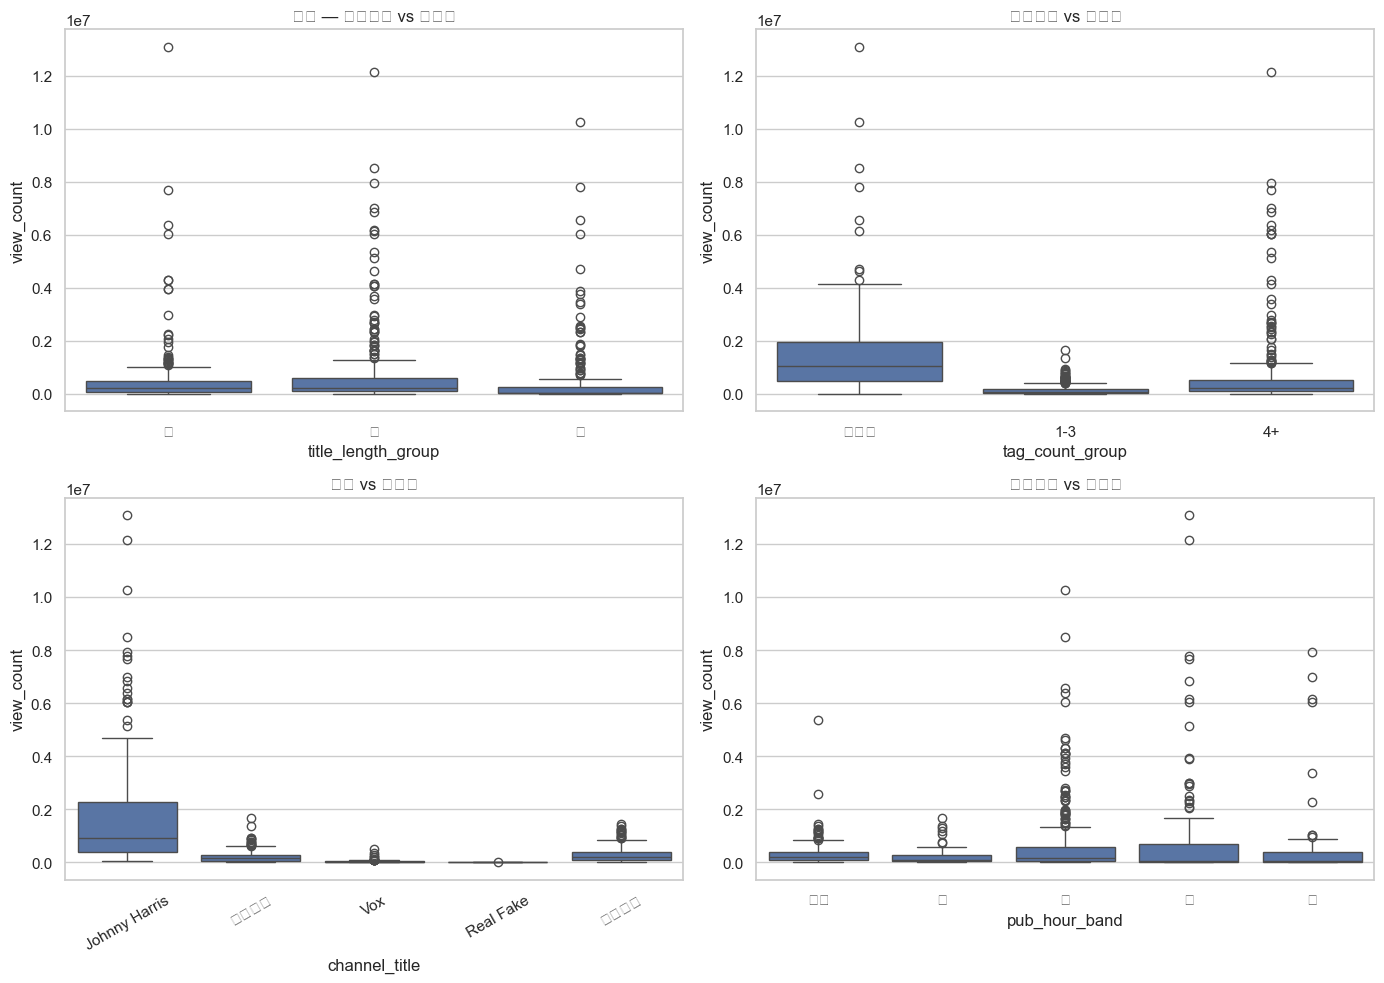

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(data=df_shorts, x='title_length_group', y='view_count', ax=axes[0,0])
axes[0,0].set_title(f'{CATEGORY_NAME} — 標題長度 vs 觀看數')
sns.boxplot(data=df_shorts, x='tag_count_group', y='view_count', ax=axes[0,1])
axes[0,1].set_title('標籤數量 vs 觀看數')
sns.boxplot(data=df_shorts, x='channel_title', y='view_count', ax=axes[1,0])
axes[1,0].set_title('頻道 vs 觀看數'); axes[1,0].tick_params(axis='x', rotation=30)
sns.boxplot(data=df_shorts, x='pub_hour_band', y='view_count', ax=axes[1,1])
axes[1,1].set_title('發佈時段 vs 觀看數')
plt.tight_layout(); plt.show()


## 12. 結論

（依分析結果手動撰寫）